In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
data = pd.read_csv('exchange_rate.csv')

In [36]:
data.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [37]:
data.isnull().sum()

date       0
Ex_rate    0
dtype: int64

In [38]:
data['date'] = pd.to_datetime(data['date'],format='%d-%m-%Y %H:%M')

data.set_index('date', inplace=True)

In [39]:
data.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


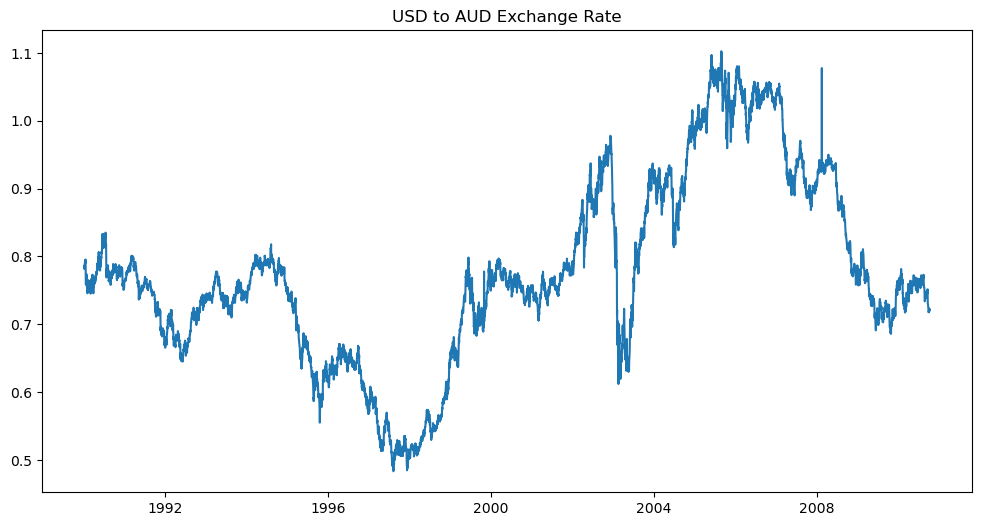

In [40]:
plt.figure(figsize=(12,6))
plt.plot(data['Ex_rate'])
plt.title("USD to AUD Exchange Rate")
plt.show()

### ARIMA Model :

#### Find p and q Using ACF and PACF :

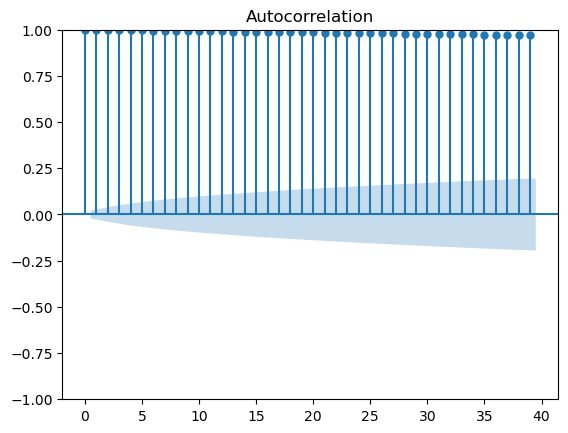

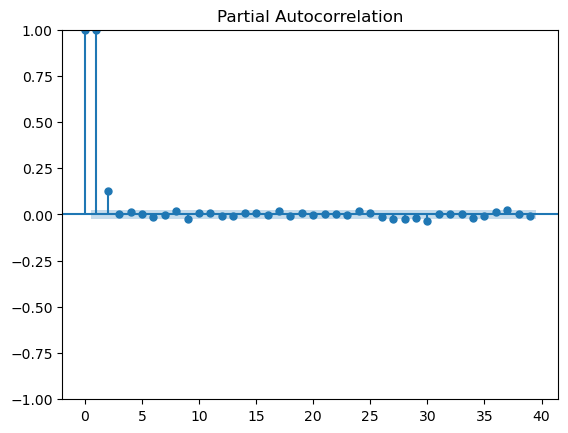

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(data['Ex_rate'])
plot_pacf(data['Ex_rate'])
plt.show()

In [42]:
data_diff = data['Ex_rate'].diff().dropna()

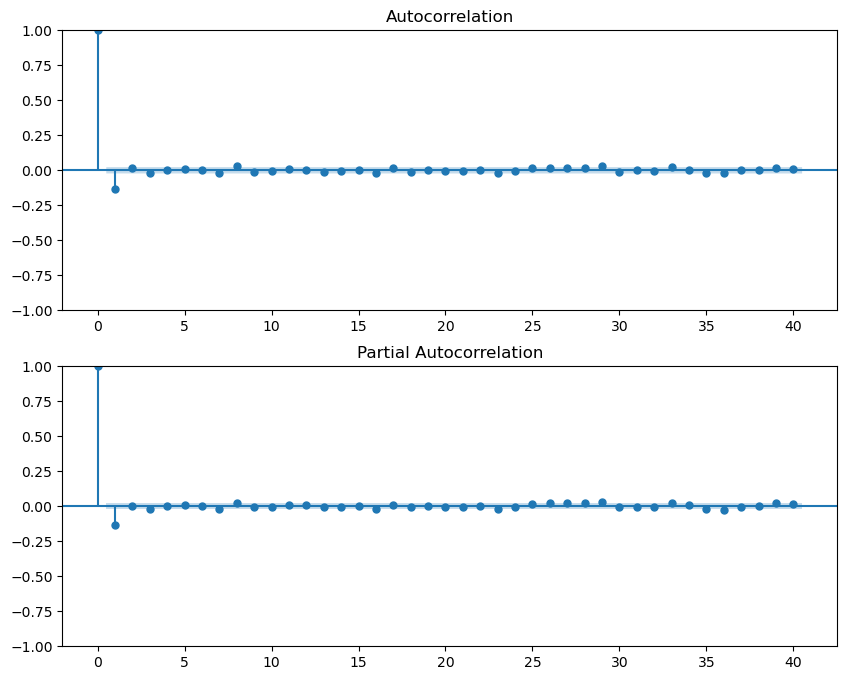

In [43]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,1, figsize=(10,8))

plot_acf(data_diff, lags=40, ax=ax[0])
plot_pacf(data_diff, lags=40, ax=ax[1])

plt.show()

#### Soo recommended  ARIMA Model : ARIMA(1,1,1)

#### Model Fitting : 

In [44]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data['Ex_rate'], order=(1,1,1))
results = model.fit()
print(results.summary())

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Thu, 04 Jun 2026   AIC                         -56102.322
Time:                        14:43:32   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

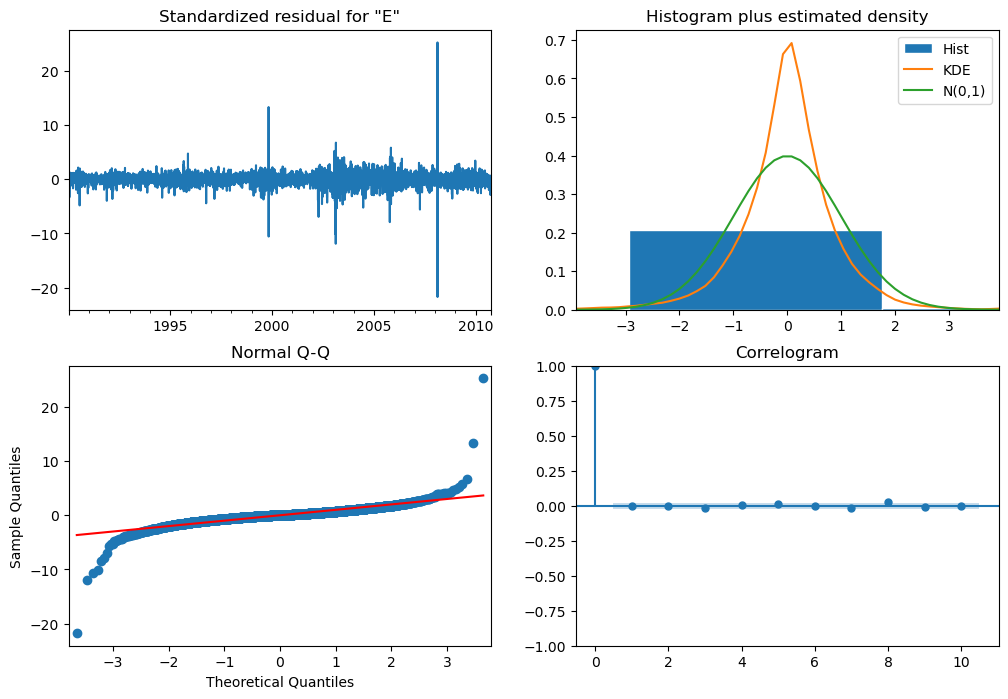

In [45]:
results.plot_diagnostics(figsize=(12,8))
plt.show()

#### Forecast Future Values :

In [46]:
forecast = results.forecast(steps=30)
print(forecast)

2010-10-11    0.720826
2010-10-12    0.720826
2010-10-13    0.720826
2010-10-14    0.720826
2010-10-15    0.720826
2010-10-16    0.720826
2010-10-17    0.720826
2010-10-18    0.720826
2010-10-19    0.720826
2010-10-20    0.720826
2010-10-21    0.720826
2010-10-22    0.720826
2010-10-23    0.720826
2010-10-24    0.720826
2010-10-25    0.720826
2010-10-26    0.720826
2010-10-27    0.720826
2010-10-28    0.720826
2010-10-29    0.720826
2010-10-30    0.720826
2010-10-31    0.720826
2010-11-01    0.720826
2010-11-02    0.720826
2010-11-03    0.720826
2010-11-04    0.720826
2010-11-05    0.720826
2010-11-06    0.720826
2010-11-07    0.720826
2010-11-08    0.720826
2010-11-09    0.720826
Freq: D, Name: predicted_mean, dtype: float64


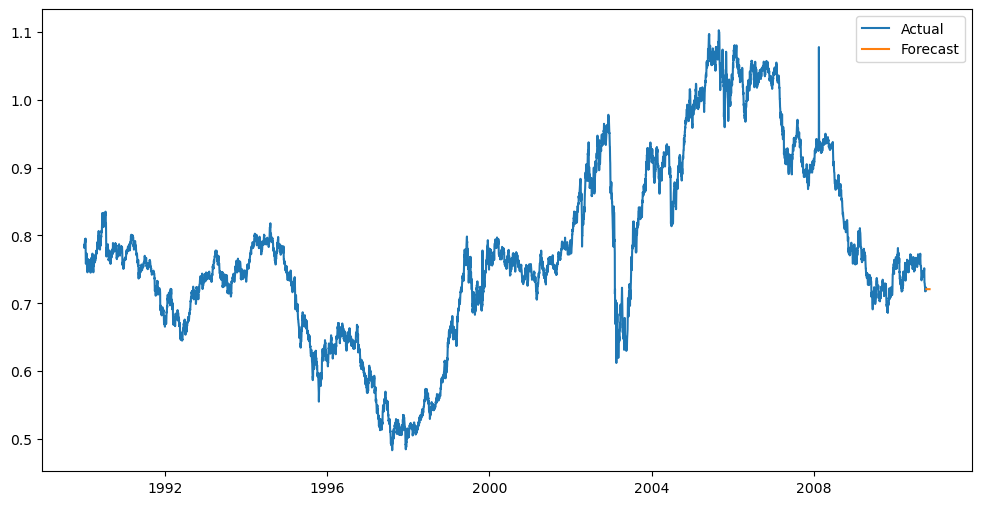

In [47]:
plt.figure(figsize=(12,6))
plt.plot(data['Ex_rate'],label='Actual')
plt.plot(forecast,label='Forecast')
plt.legend()
plt.show()

In [48]:
forecast = results.forecast(steps=30)

print(forecast)
print(len(forecast))

2010-10-11    0.720826
2010-10-12    0.720826
2010-10-13    0.720826
2010-10-14    0.720826
2010-10-15    0.720826
2010-10-16    0.720826
2010-10-17    0.720826
2010-10-18    0.720826
2010-10-19    0.720826
2010-10-20    0.720826
2010-10-21    0.720826
2010-10-22    0.720826
2010-10-23    0.720826
2010-10-24    0.720826
2010-10-25    0.720826
2010-10-26    0.720826
2010-10-27    0.720826
2010-10-28    0.720826
2010-10-29    0.720826
2010-10-30    0.720826
2010-10-31    0.720826
2010-11-01    0.720826
2010-11-02    0.720826
2010-11-03    0.720826
2010-11-04    0.720826
2010-11-05    0.720826
2010-11-06    0.720826
2010-11-07    0.720826
2010-11-08    0.720826
2010-11-09    0.720826
Freq: D, Name: predicted_mean, dtype: float64
30


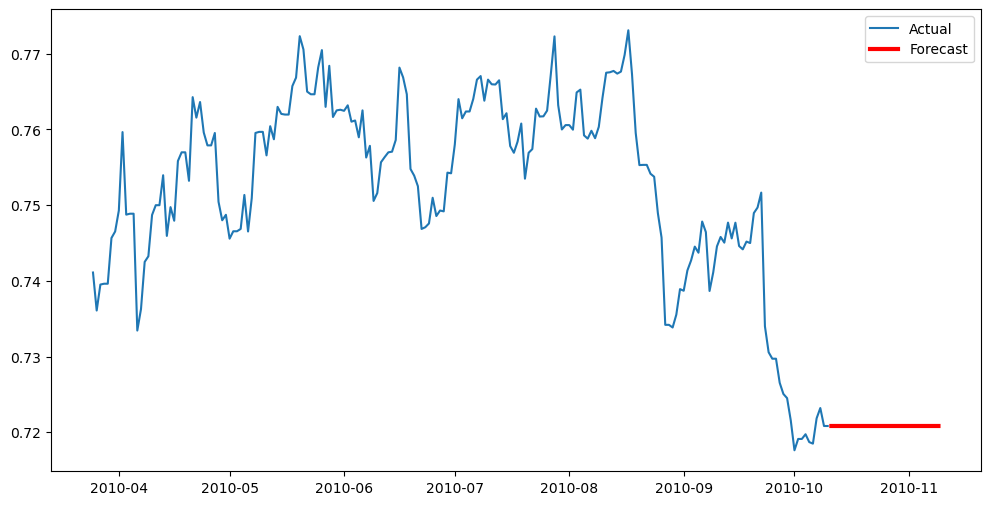

In [49]:
plt.figure(figsize=(12,6))

plt.plot(data['Ex_rate'].iloc[-200:],
         label='Actual')

plt.plot(forecast.index,
         forecast,
         color='red',
         linewidth=3,
         label='Forecast')

plt.legend()
plt.show()

#### Split Data into Train/Test :

In [50]:
train = data['Ex_rate'][:-30]
test = data['Ex_rate'][-30:]

model = ARIMA(train, order=(1,1,1))
results = model.fit()

forecast = results.forecast(steps=30)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


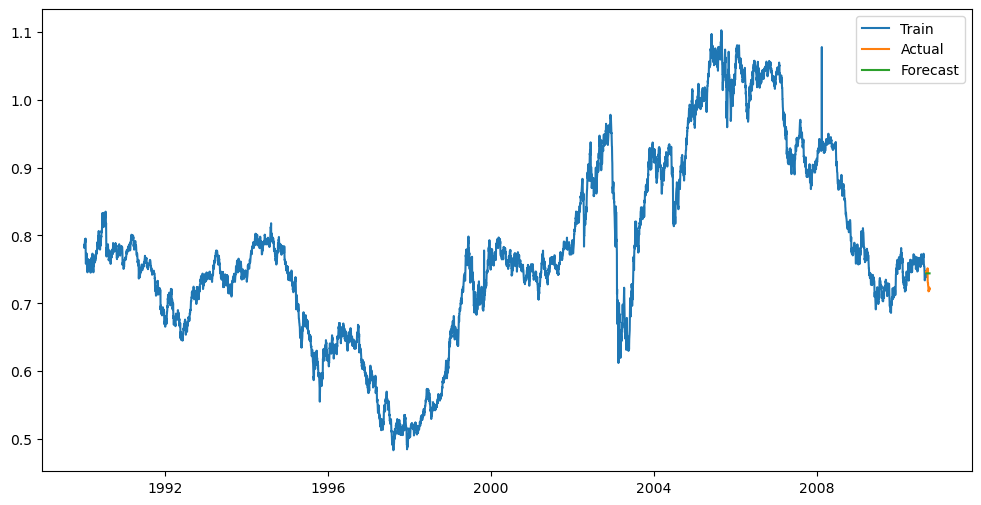

In [51]:
plt.figure(figsize=(12,6))

plt.plot(train.index,
         train,
         label='Train')

plt.plot(test.index,
         test,
         label='Actual')

plt.plot(test.index,
         forecast,
         label='Forecast')

plt.legend()
plt.show()

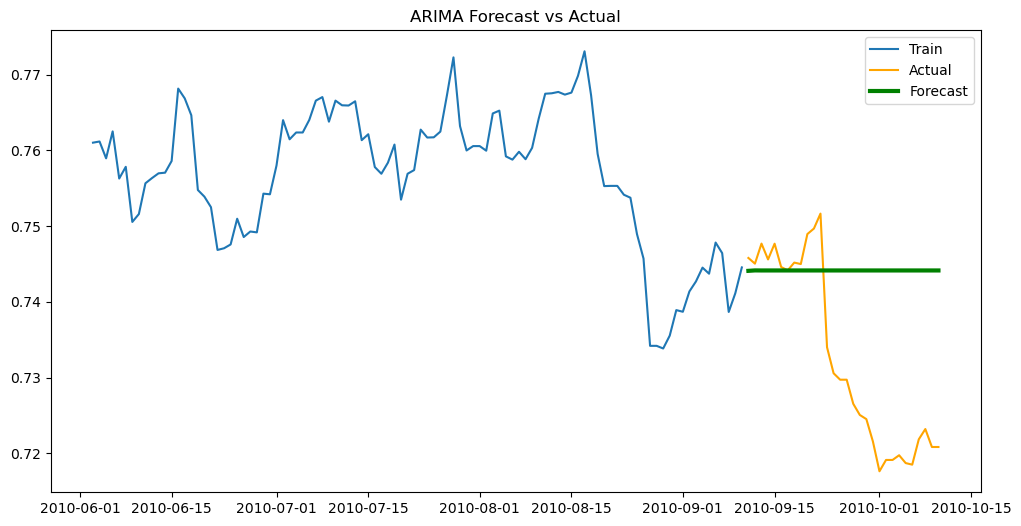

In [52]:
plt.figure(figsize=(12,6))

plt.plot(train.iloc[-100:], label='Train')
plt.plot(test, label='Actual', color='orange')
plt.plot(forecast, label='Forecast', color='green', linewidth=3)

plt.legend()
plt.title('ARIMA Forecast vs Actual')
plt.show()

### Conclusion :

- Historical exchange rate data was analyzed using ARIMA and Exponential Smoothing models.
- The dataset was preprocessed by converting the date column to datetime format, setting it as the index, and checking for missing values.
- Stationarity was assessed using the Augmented Dickey-Fuller (ADF) test, and first-order differencing was applied before fitting the ARIMA model.
- Forecasts from both models were evaluated using MAE, RMSE, and MAPE. 
- The model with the lower error values was considered the better forecasting model for the given exchange rate dataset.